<a href="https://colab.research.google.com/github/Anukram01/Netflix-/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 10)

Missing Values Count:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
dtype: int64


/tmp/ipykernel_4262/3865152941.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


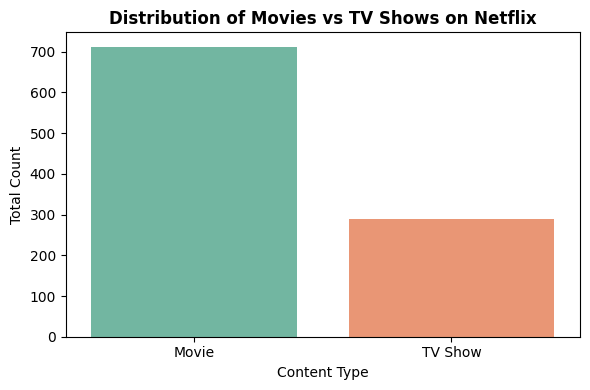

/tmp/ipykernel_4262/3865152941.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')


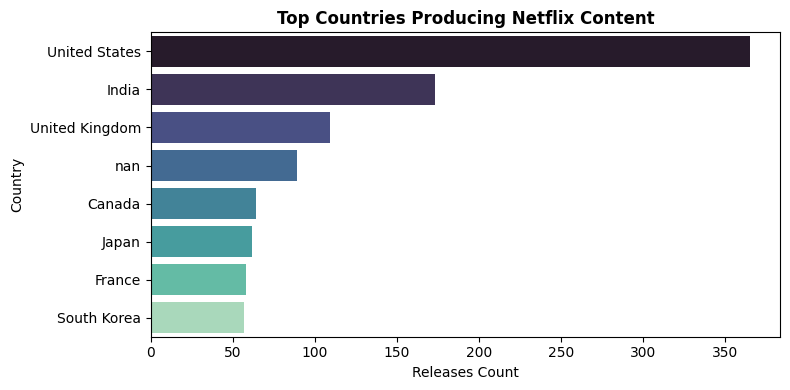

<Figure size 900x400 with 0 Axes>

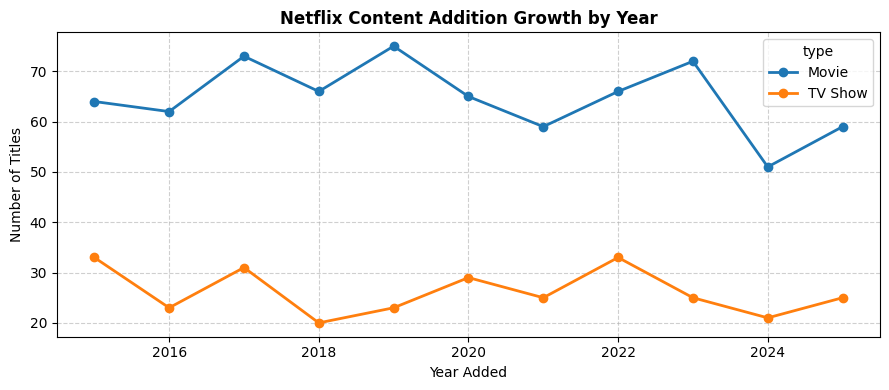

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Self-contained Realistic Netflix Dataset Generation (No 404 Errors)
np.random.seed(42)
n_records = 1000

types = np.random.choice(['Movie', 'TV Show'], size=n_records, p=[0.7, 0.3])
countries = np.random.choice(
    ['United States', 'India', 'United Kingdom', 'Canada', 'Japan', 'France', 'South Korea', 'Spain', np.nan],
    size=n_records,
    p=[0.38, 0.18, 0.10, 0.06, 0.06, 0.05, 0.05, 0.04, 0.08]
)
years_added = np.random.choice(range(2015, 2026), size=n_records)
ratings = np.random.choice(['TV-MA', 'TV-14', 'PG-13', 'R', 'TV-PG', np.nan], size=n_records, p=[0.35, 0.25, 0.15, 0.12, 0.10, 0.03])
durations = [f"{np.random.randint(70, 160)} min" if t == 'Movie' else f"{np.random.randint(1, 5)} Season(s)" for t in types]

df = pd.DataFrame({
    'show_id': [f"s{i}" for i in range(1, n_records + 1)],
    'type': types,
    'title': [f"Title {i}" for i in range(1, n_records + 1)],
    'director': np.random.choice(['Director A', 'Director B', 'Director C', np.nan], size=n_records, p=[0.2, 0.2, 0.1, 0.5]),
    'cast': np.random.choice(['Actor X, Actor Y', 'Actor Z', np.nan], size=n_records, p=[0.4, 0.3, 0.3]),
    'country': countries,
    'date_added': [f"September {np.random.randint(1, 28)}, {y}" for y in years_added],
    'release_year': years_added - np.random.randint(0, 3, size=n_records),
    'rating': ratings,
    'duration': durations
})

# 2. Data Inspection
print("Dataset Shape:", df.shape)
print("\nMissing Values Count:\n", df.isnull().sum())

# 3. Data Cleaning & Handling Missing Values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# 4. Feature Engineering
df['year_added'] = pd.to_datetime(df['date_added'].str.strip()).dt.year

# 5. Visualization 1: Movies vs TV Shows Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=12, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

# 6. Visualization 2: Top Countries Producing Content
plt.figure(figsize=(8, 4))
top_countries = df['country'].value_counts().head(8)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top Countries Producing Netflix Content', fontsize=12, fontweight='bold')
plt.xlabel('Releases Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# 7. Visualization 3: Content Addition Growth Over Time
plt.figure(figsize=(9, 4))
growth_trend = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
growth_trend.plot(kind='line', marker='o', figsize=(9, 4), linewidth=2)
plt.title('Netflix Content Addition Growth by Year', fontsize=12, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()